#### Get Predictions

In [2]:
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np

In [28]:
# Load test Set
x_test_set = pd.read_csv("./data/x_test_set.csv")
y_test_set = pd.read_csv("./data/y_test_set.csv")

In [5]:
!ls

checkList.ipynb  imgs/                  model_random_forset.ipynb*
data/            learn/                 my_model.pkl
eda.ipynb*       model_anaylsing.ipynb  README.md


In [7]:
# Load The Model
# model = joblib.load("./drive/MyDrive/git_projects/my_model.pkl")
model = joblib.load("./my_model.pkl")
model

/home/abdellah/.local/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/abdellah/.local/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [26]:
# Prediction
y_pred = model.predict(x_test_set)
y_pred

array([188750.73 , 177517.65 , 169483.845, ..., 267582.4  , 254995.93 ,
       363306.625])

In [9]:
# Get Test Dataset Frame
y_test_df = pd.DataFrame(y_test_set, columns=["salary"])
y_test_df.reset_index(inplace=True)
y_test_df = y_test_df.drop("index", axis=1)
y_test_df.head(3)

,salary
0,176284.0
1,157717.0
2,186763.0


In [10]:
# Get Predction DataSet Frame
y_pred_df = pd.DataFrame(y_pred, columns=["salary_pred"])
y_pred_df.head(3)

,salary_pred
0,188750.730
1,177517.650
2,169483.845


In [11]:
# Combine The Two DataSet
y_pred_real_df = pd.concat([y_pred_df, y_test_df], axis=1)
y_pred_real_df.head(3)

,salary_pred,salary
0,188750.730,176284.0
1,177517.650,157717.0
2,169483.845,186763.0


#### Model Improvements

In [ ]:
# Random Forest Hyperparameter Tuning
'''
    - n_estimators: number of trees in forset, more trees improve the model but increase cost
    - max_features: limit number of features when splitting a node --> this help control overfitting
    - max_depth: control max depth for each tree
    - max_leaf_nodes: limit number of leaf node for each tree
    - max_sample: how much of dataset given to each tree
    - min_samples_split: specify the number of smaples required to split an internal node
    
    --> GridSearchCV and RandomizedSearchCV are Technics Used to Discover The bEst Parameters.
'''


In [12]:
'''
    - Result Regression Visualisation
    - MAE (Mean Absolute Error) → average difference
    - RMSE (Root Mean Squared Error) → penalizes big errors
    - Residuals
    - R² → % of variance explained by model
    - Feature Importance: mesure how much each feature combined to the model
    - Update The Model Paramters like (n_estimators, max_depth, max_features, ...) WITH GridSearchCV
'''

# Visualtion Of MEA, RMSE, ...
# How we can use This MEA, .. to improve the model
# Improve Model Performance

'\n    - Result Regression Visualisation\n    - MAE (Mean Absolute Error) → average difference\n    - RMSE (Root Mean Squared Error) → penalizes big errors\n    - Residuals\n    - R² → % of variance explained by model\n    - Feature Importance: mesure how much each feature combined to the model\n    - Update The Model Paramters like (n_estimators, max_depth, max_features, ...) WITH GridSearchCV\n'

In [23]:
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, r2_score as r_2, classification_report
from math import sqrt
import matplotlib.pyplot as plt

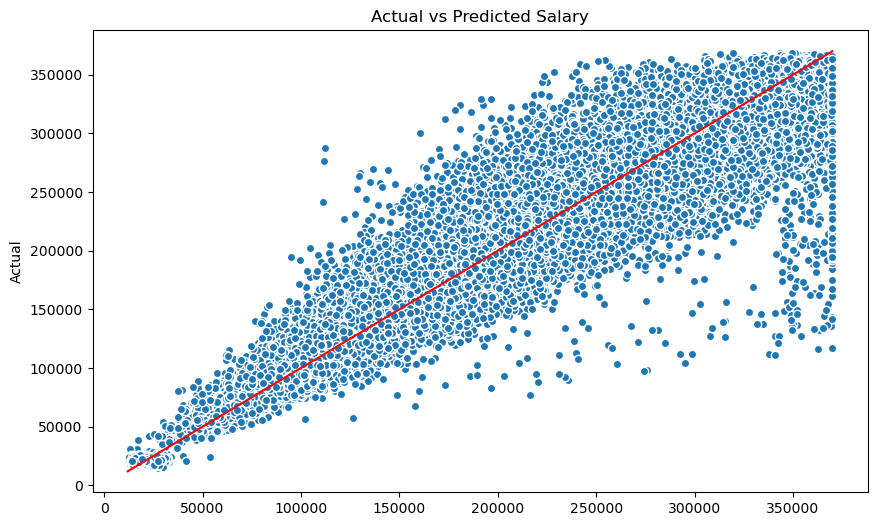

In [14]:
# Visualizing The Regression Results: Predicted vs Actual Visualtion
# FROM: https://codesignal.com/learn/courses/regression-analysis-to-model-diamond-prices/lessons/visualizing-actual-vs-predicted-prices-in-regression-models

plt.figure(figsize=(10, 6))

# Add Scatter For Visuale The Points
plt.scatter(y_pred_real_df["salary"], y_pred_real_df["salary_pred"], edgecolors="w")
plt.ylabel("Prediction")
plt.ylabel("Actual")
plt.title('Actual vs Predicted Salary')

# Visuale The Line For The Prefect Prediction
limits = [y_pred_real_df["salary"].min(), y_pred_real_df["salary"].max()]
plt.plot(limits, limits, color="red", linestyle="-", ) # draw line with coordinate (x1, y1) and (x2, y2)

In [15]:
# Get Mean Absolute Error (MAE)
mae_val = sum(abs(y_pred_real_df["salary"] - y_pred_real_df["salary_pred"])) / y_pred_real_df["salary"].size
print(mae_val)
mae(y_pred=y_pred_real_df["salary_pred"], y_true=y_pred_real_df["salary"])

22907.01938197619


22907.01938197619

In [16]:
# Root Mean Squared Error (RMSE)
len = y_pred_real_df["salary_pred"].count()
rmse_val = sqrt(sum(pow(y_pred_real_df["salary"] - y_pred_real_df["salary_pred"], 2)) / len)
print(rmse_val)
rmse(y_pred=y_pred_real_df["salary_pred"], y_true=y_pred_real_df["salary"])

32048.177556673665


32048.177556673665

In [17]:
# Get R²
mean_y_test_set = y_pred_real_df["salary_pred"].mean()
r_2_val = 1 - (sum(pow(y_pred_real_df["salary"] - y_pred_real_df["salary_pred"], 2)) / sum(pow(y_pred_real_df["salary"] - mean_y_test_set, 2)))
print(r_2_val)

r_2(y_pred=y_pred_real_df["salary_pred"], y_true=y_pred_real_df["salary"])

0.8606356460346503


0.8606356370041295

In [32]:
# Get Adjustement R²


<BarContainer object of 71 artists>

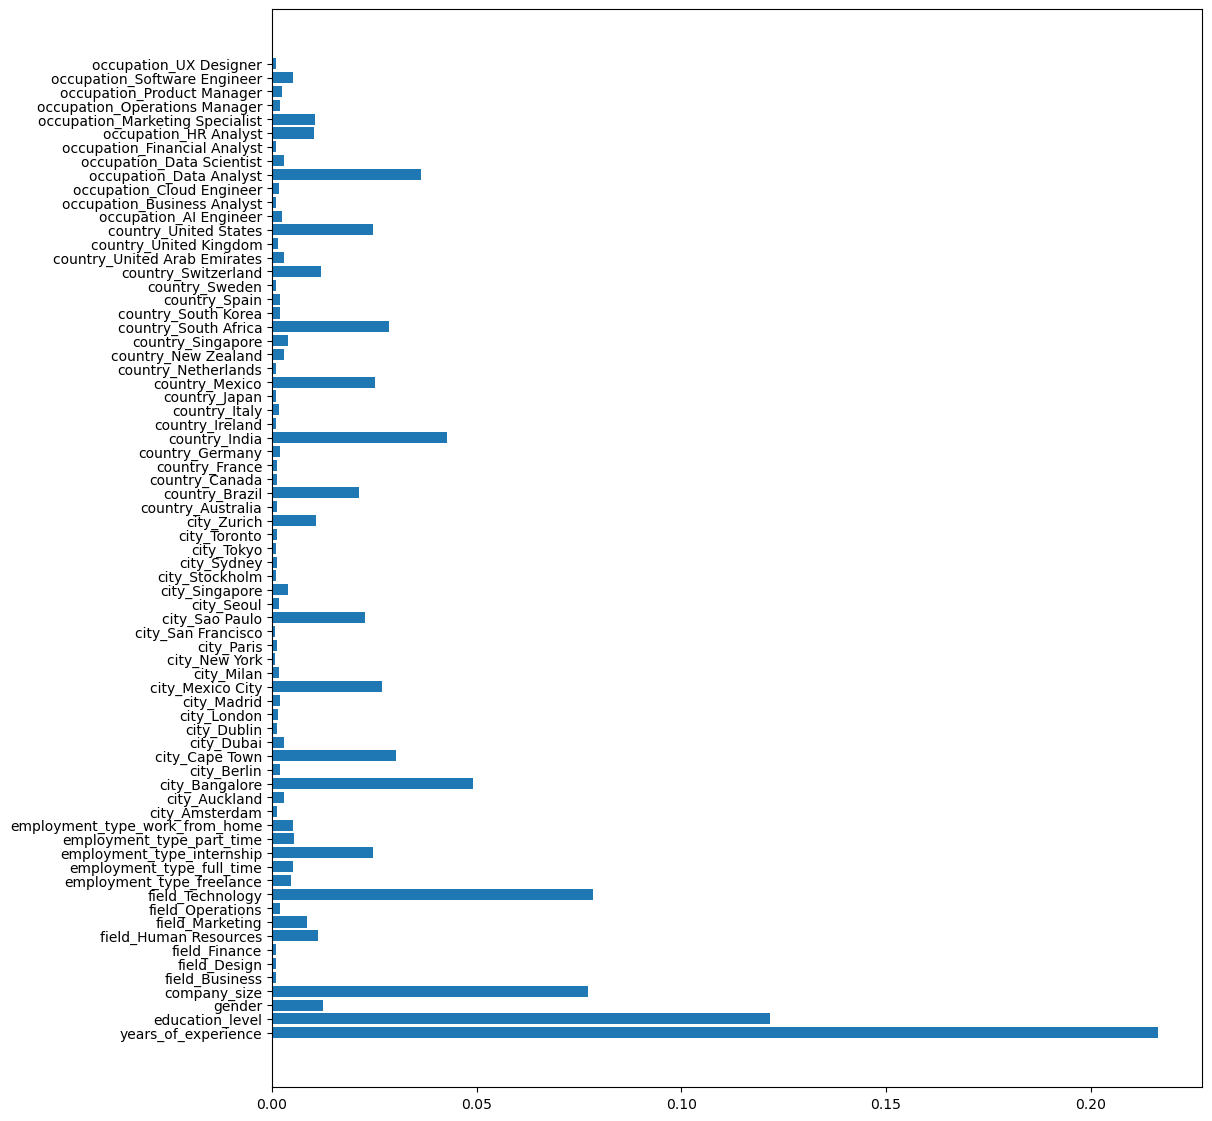

In [20]:
# Features Importance
features_names = list(model.feature_names_in_)
features_importances = list(model.feature_importances_)

# Visuale The Feature Importance
plt.figure(figsize=(12, 14))
plt.barh(features_names, features_importances)